### Data discovery - Burgers' PDE

##### Along with training the model, we find $\lambda_{1}$ and $\lambda_{2}$:

$$u_{t} + \lambda_{1} u u_{x} - \lambda_{2} u_{xx} = 0$$

In [31]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
from time import time
import tensorflow_probability as tfp

print ( tf.config.list_physical_devices ( 'GPU' ) )
print ( "Libraries imported" )

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Libraries imported


In [32]:
adam_epochs = 40000
lbfgs_epochs = 0

N = 2000
Nf = 20000

#### We sample 2000 data points for training. We are not provided with initial or boundary conditions.

In [33]:
data = loadmat ( "burgers_shock.mat" )
x_val = data['x']
t_val = data['t']
u_exact_org = data['usol']

X, T = np.meshgrid ( x_val.squeeze(), t_val.squeeze(), indexing = 'ij' )

X_T = np.hstack ( [ X.reshape ( -1, 1 ), T.reshape ( -1, 1 ) ] )
u_exact = u_exact_org.reshape ( -1, 1 )

rows = X_T.shape[0]

rng = np.random.default_rng()
indices = rng.choice ( np.arange ( 0, rows ), size = N, replace = False )

x_train = X_T[indices]
y_train = u_exact[indices]

x = np.random.uniform ( -1, 1, ( Nf, 1 ) )
t = np.random.uniform ( 0, 1, ( Nf, 1 ) )

x_tf = tf.convert_to_tensor ( x, dtype = tf.float32 )
t_tf = tf.convert_to_tensor ( t, dtype = tf.float32 )

fx_train = np.hstack ( ( x, t ) )

print ( X_T.shape, u_exact.shape, x_train.shape, y_train.shape, fx_train.shape )

(25600, 2) (25600, 1) (2000, 2) (2000, 1) (20000, 2)


#### Initially set both parameters to 0.

In [34]:
lambda_1 = tf.Variable ( 0.0, dtype = tf.float32, name = "lambda_1" )
lambda_2 = tf.Variable ( 0.0, dtype = tf.float32, name = "lambda_2" )

##### We use Xavier initialization.

In [35]:

model = tf.keras.Sequential ( [
        tf.keras.layers.InputLayer ( input_shape = ( 2, ) ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 50, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 1 )
    ] )

print ( model.summary() )

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,601 (80.47 KB)

 Trainable params: 20,601 (80.47 KB)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
@tf.function
def MSE_u():
    return tf.reduce_mean ( tf.square ( model ( x_train ) - y_train ) )

@tf.function
def MSE_f():    
    with tf.GradientTape ( persistent = True ) as tape2:
        tape2.watch ( [ x_tf, t_tf ] )
        with tf.GradientTape ( persistent = True ) as tape1:
            tape1.watch ( [ x_tf, t_tf ] )
            u_pred = model ( tf.concat ( [x_tf, t_tf], axis = 1 ) )
        
        du_dx = tape1.gradient ( u_pred, x_tf )
        du_dt = tape1.gradient ( u_pred, t_tf )
    
    d2u_dx2 = tape2.gradient ( du_dx, x_tf )
    return tf.reduce_mean ( tf.square ( du_dt + ( lambda_1 * u_pred * du_dx ) - ( lambda_2 * d2u_dx2 ) ) )

In [37]:
opt = tf.keras.optimizers.AdamW ( learning_rate = 1e-3, weight_decay = 0.0 )

print ( "INFO: Training Started" )
start = time()

for epoch in range ( 1, adam_epochs + 1 ):
    with tf.GradientTape() as tape:
        loss = MSE_u() + MSE_f()

    all_trainable_vars = model.trainable_variables + [ lambda_1, lambda_2 ]

    grads = tape.gradient ( loss, all_trainable_vars )
    opt.apply_gradients ( zip ( grads, all_trainable_vars ) )
    
    if ( epoch % 1000 == 0 ):
        print ( "INFO: Adam Epoch {} reached; Time elapsed: {}\nlambda_1: {}; lambda_2: {}\nMSE_u : {}, MSE_f: {}\n".format ( str ( epoch ), str ( time() - start ), str ( lambda_1.numpy() ), str ( lambda_2.numpy() ), str ( float ( MSE_u() ) ), str ( float ( MSE_f() ) ) ) )

    if ( epoch == 5000 ):
        print ( "INFO: Adam Learning rate now 0.0001 and decay 0.0001" )
        opt.learning_rate.assign ( 1e-4 )
        opt.weight_decay = 1e-4

    if ( epoch == 25000 ):
        print ( "INFO: Adam Learning rate now 0.00001" )
        opt.learning_rate.assign ( 1e-5 )
        opt.weight_decay = 1e-4

print ( "INFO: Training with Adam done" )


INFO: Training Started
INFO: Adam Epoch 1000 reached; Time elapsed: 26.055017709732056
lambda_1: 0.39065102; lambda_2: 0.0023613186
MSE_u : 0.010848690755665302, MSE_f: 0.007275393698364496

INFO: Adam Epoch 2000 reached; Time elapsed: 51.84743046760559
lambda_1: 0.6183964; lambda_2: 0.0037588198
MSE_u : 0.00599463889375329, MSE_f: 0.023010123521089554

INFO: Adam Epoch 3000 reached; Time elapsed: 77.566486120224
lambda_1: 0.7353765; lambda_2: 0.0043057525
MSE_u : 0.002468093764036894, MSE_f: 0.0016839363379403949

INFO: Adam Epoch 4000 reached; Time elapsed: 103.30359196662903
lambda_1: 0.8084452; lambda_2: 0.004579942
MSE_u : 0.0032566827721893787, MSE_f: 0.0026597310788929462

INFO: Adam Epoch 5000 reached; Time elapsed: 129.0127968788147
lambda_1: 0.85352886; lambda_2: 0.005120887
MSE_u : 0.0010253617074340582, MSE_f: 0.00010392432159278542

INFO: Adam Learning rate now 0.0001 and decay 0.0001
INFO: Adam Epoch 6000 reached; Time elapsed: 154.76221084594727
lambda_1: 0.8604731; lamb

#### We get an error better than what we reported for the original implementation.

Our final lambda values: $(0.996, 0.00323)$; \
Actual values: $(1, 0.00318)$

In [38]:
u_pred = model.predict ( X_T ).reshape ( u_exact.shape )
print ( "Relative L2 Error: ", np.linalg.norm ( u_pred - u_exact ) / np.linalg.norm ( u_exact ) )

800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 392us/step
Relative L2 Error:  0.002645239682084778


800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step


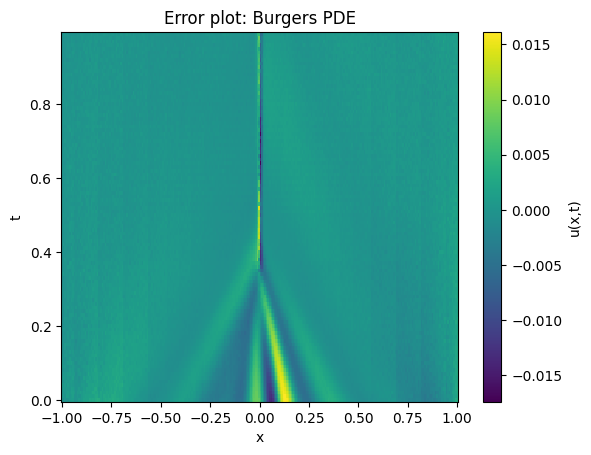

In [41]:
u = model.predict ( X_T ).reshape ( u_exact_org.shape )

plt.pcolormesh ( X, T, u_exact_org - u )
plt.colorbar ( label = "u(x,t)" )
plt.xlabel ( "x" )
plt.ylabel ( "t" ) 
plt.title ( "Error plot: Burgers PDE" )
plt.show()